In [2]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [3]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
pfns = PlottingFns()

In [4]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean

from tqdm import tqdm
from gsw import density

ROOT = '/nfs/b0133/eejco/data/MEOP_2024/media/disk2/roquet/MEOP_public/MEOP-CTD_2024-03-08/'
FNAME_PROFILES = ROOT + 'list_profiles.csv'
FNAME_TAGS = ROOT + 'list_tags.csv'
FNAME_DEPLOYMENTS = ROOT + 'list_deployments.csv'




In [5]:
#define helper functions
def is_in(profile,extent):
        return ((profile.LATITUDE <= extent[3]) & 
                (profile.LATITUDE >= extent[2]) &
                (profile.LONGITUDE <= extent[1]) &
                (profile.LONGITUDE >= extent[0])
        )

def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

In [6]:
# locations of interest
glaciers = dict()
glaciers['conger'] = [103, -66.3]
glaciers['totten'] = [116.5, -66.3]
glaciers['vanderford'] = [110, -66]
glaciers['denman'] = [99.5, -66.75]
glaciers['mertz'] = [144.76, -67.5]
glaciers['dibble'] = [134.5, -66.25]

In [7]:
# define study area
sabrina = [115,122,-70,-67.5]
wilkes = [100,136,-70,-60]
shackleton_sabrina = [95,122,-67.5,-64]
adelie = [120,170,-70,-64]
prydz = [50, 100,-70, -65]
vincennes_bay = [106,112,-67,-65]

In [8]:
lwe_ds = GRACE().ds
sla = SLA(deg=0.25).da
dot_ds = DOT().ds

In [9]:
elevation_ = GEBCO(coarsen_factor=10).ds.elevation

In [10]:
data_extent = vincennes_bay
map_extent = [103,116,-67,-63]

In [11]:
class Profile():
    def __init__(self,ds):
        self.latitude = ds.LATITUDE
        self.longitude = ds.LONGITUDE
        self.time = np.datetime64(ds.JULD.item().strftime('%Y-%m-%dT%H:%M:%S'))

        coords = {'pressure': ds.PRES_ADJUSTED}
        self.ds = xr.Dataset(
            {'temperature': xr.DataArray(ds.TEMP_ADJUSTED, coords=coords),
             'salinity': xr.DataArray(ds.PSAL_ADJUSTED, coords=coords)}
        )

In [12]:
# crop elevation
elevation = elevation_.sel(latitude = slice(map_extent[2], map_extent[3]), longitude = slice(map_extent[0],map_extent[1]))

In [13]:
# read deployments
deployments = pd.read_csv(FNAME_DEPLOYMENTS)

In [14]:
# read profiles and trim to latitudes we care about
profiles_ = pd.read_csv(FNAME_PROFILES)
profiles_ = profiles_[is_in(profiles_,[d + 5 for d in map_extent])] # the lat, lon on this list is the start point, so expand the area 


In [15]:
# define methods to retrieve info one each profile
deployment = lambda platform: str.split(platform,'-')[0]
country = lambda platform: str(deployments[deployments.DEPLOYMENT_CODE == deployment(platform)].COUNTRY.item())
folder = lambda platform: ROOT + country(platform) + '/DATA/'
filename = lambda platform: platform + '_all_prof.nc'

profile_codes=profiles_.SMRU_PLATFORM_CODE.unique()

flatten = lambda l: [item for sublist in l for item in sublist]   

In [16]:
# gather profiles in desired area, discard others
profiles = []
for pc in tqdm(profile_codes):
    fname = folder(pc)+filename(pc)
    ds = xr.open_dataset(fname)

    in_area = is_in(ds,data_extent)

    if any(in_area):
        for n in ds.N_PROF.where(in_area,drop=True):
            profiles.append(Profile(ds.sel(N_PROF=int(n))))
            # profile = ds.sel(N_PROF=n)
            # if is_in(profile,data_extent):
            #     entry = build_entry(profile,fname)
            #     if len(entry)>0:
            #         profile_dicts.append(entry)

  0%|          | 0/41 [00:00<?, ?it/s]

100%|██████████| 41/41 [00:06<00:00,  6.74it/s]


In [17]:
lats = [p.latitude for p in profiles]
lons = [p.longitude for p in profiles]
sst = [p.ds.temperature.isel(N_LEVELS=0) for p in profiles]
times = [p.time for p in profiles]

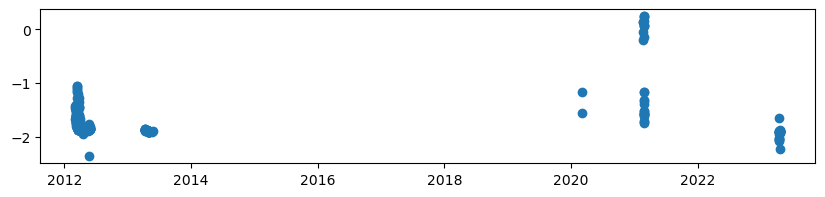

In [18]:
fig,ax = plt.subplots(figsize=(10,2))
ax.scatter(times,sst)

In [19]:
years = [t.astype('datetime64[Y]').astype(int) + 1970 for t in times]

In [20]:
from itertools import compress

In [21]:
set(years)

{2012, 2013, 2020, 2021, 2023}

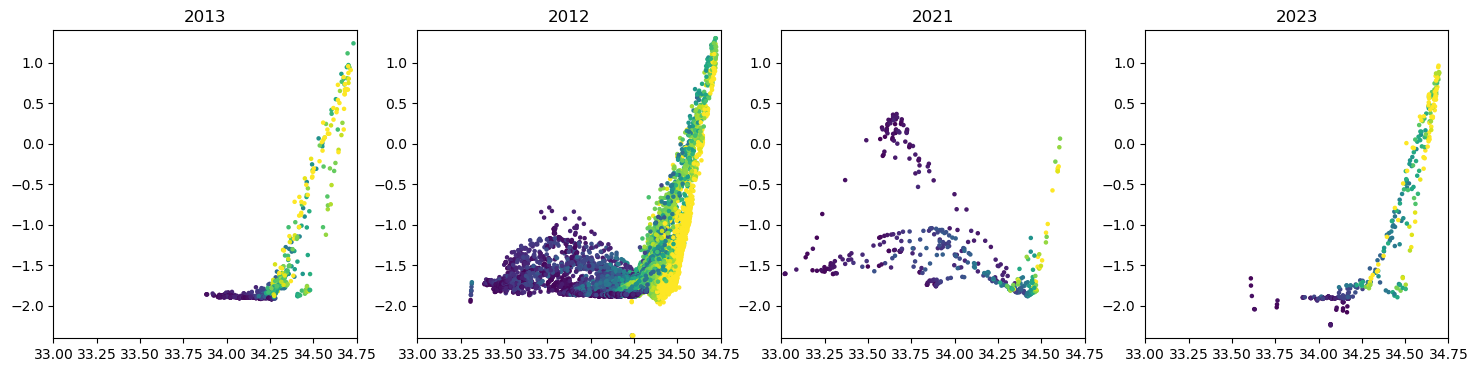

In [22]:
fig, ax = plt.subplots(1,4,figsize=(18,4))

for i,y in enumerate({2012,2013,2021,2023}):
    idx = (np.equal(years,y))
    for profile in list(compress(profiles,idx)):
        im=ax[i].scatter(profile.ds.salinity,profile.ds.temperature,5,profile.ds.pressure,vmin=0,vmax=500)
        ax[i].set_title(str(y))
        ax[i].set_ylim([-2.4,1.4])
        ax[i].set_xlim([33,34.75])

    
    #plt.colorbar(im)
    

In [ ]:
#load slowly
sla_2012 = sla.sel(time=slice(pd.Timestamp(2012,7,1),pd.Timestamp(2012,9,30))).mean('time')
sla_2013 = sla.sel(time=slice(pd.Timestamp(2013,7,1),pd.Timestamp(2013,9,30))).mean('time')
sla_2021 = sla.sel(time=slice(pd.Timestamp(2021,7,1),pd.Timestamp(2021,9,30))).mean('time')
sla_2023 = sla.sel(time=slice(pd.Timestamp(2023,7,1),pd.Timestamp(2023,9,30))).mean('time')


NameError: name 'sla' is not defined

In [ ]:
fig, ax = plt.subplots(1,4,figsize=(16,5), subplot_kw={"projection":ccrs.Mercator()})

pfns.sp(ax[0],sla_2012,title='2012',extent=map_extent,cbar="SLA/cm",vmin=-2,vmax=2,cbar_orientation='vertical',land_zorder=2)


KeyboardInterrupt: 

Exception ignored in: 'pyproj._datadir.pyproj_log_function'
Traceback (most recent call last):
  File "/nfs/b0133/eejco/miniconda3/envs/sha-env/lib/python3.10/logging/__init__.py", line 1455, in debug
    def debug(self, msg, *args, **kwargs):
KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(1,4,figsize=(18,4), subplot_kw={'projection':ccrs.Mercator()})

for i,y in enumerate({2012,2013,2021,2023}):
    idx = (np.equal(years,y))
    for profile in list(compress(profiles,idx)):
        ax[i].set_title(str(y))
        pfns.sp(ax=ax[i],da=elevation,extent=map_extent)
        #im=ax[i].scatter(profile.longitude, profile.latitude, transform=ccrs.PlateCarree())
        

Error in callback <function _draw_all_if_interactive at 0x7fa4d5aaf9a0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7fa4d5aaedd0> (for post_execute):


KeyboardInterrupt: 

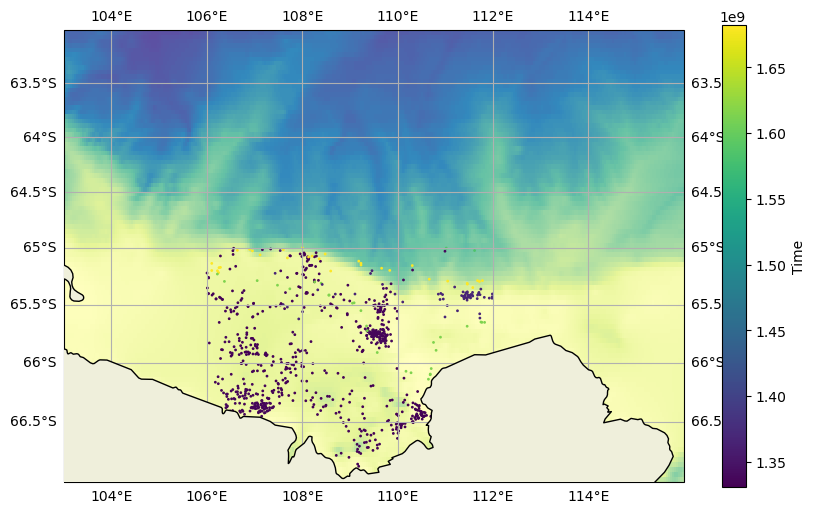

In [ ]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.Mercator()})
pfns.sp(ax=ax,da=elevation,extent=map_extent)
im=ax.scatter(lons, lats, [1 for t in times], times, transform=ccrs.PlateCarree())
plt.colorbar(im, label='Time')

In [ ]:
# crop datasets to chosen area
sla = crop_to_extent(sla,map_extent)
lwe = crop_to_extent(lwe_ds,map_extent).lwe_thickness
dot = crop_to_extent(dot_ds,map_extent).dot

In [ ]:
sla_seasons = season_split(sla)
dot_seasons = season_split(dot)
lwe_seasons = season_split(lwe)

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(16,5), subplot_kw={"projection":ccrs.Mercator()})
pfsp = lambda ax, yr: pfns.sp(ax,sla.sel(time=slice(pd.Timestamp(yr,7,1),pd.Timestamp(yr,9,30))),title=yr,extent=map_extent,cbar="SHA/cm",vmin=-0.7,vmax=0.7,cbar_orientation='vertical',land_zorder=2)

for i,y in enumerate({2012,2013,2021,2023}):
    idx = (np.equal(years,y))
    for profile in list(compress(profiles,idx)):
        ax[i].set_title(str(y))
        pfsp(ax[i],y)




NameError: name 'plt' is not defined

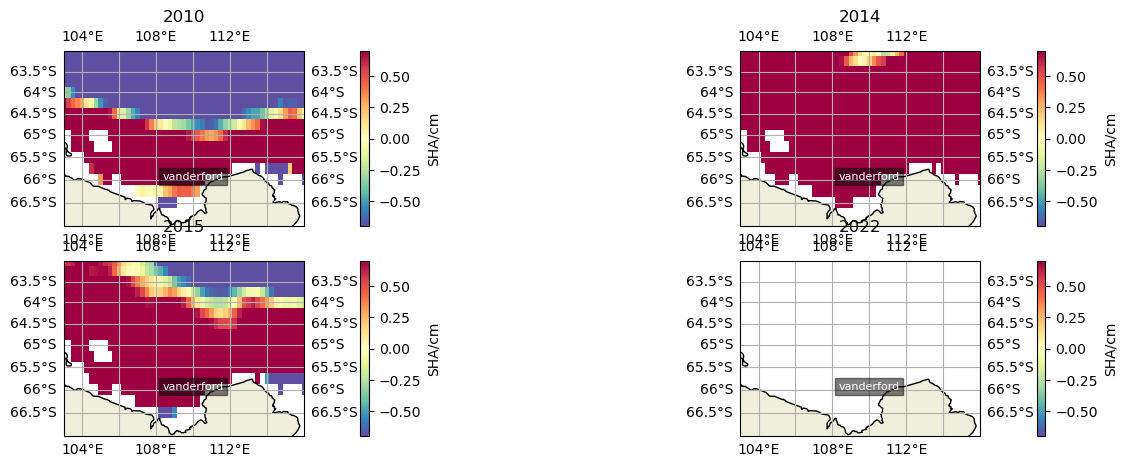

In [28]:
fig, ax = plt.subplots(2,2,figsize=(16,5), subplot_kw={"projection":ccrs.Mercator()})

pfsp = lambda ax, yr: pfns.sp(ax,sla.sel(time=slice(pd.Timestamp(yr,1,1),pd.Timestamp(yr,12,31))).mean('time'),title=yr,extent=map_extent,cbar="SHA/cm",vmin=-0.7,vmax=0.7,cbar_orientation='vertical',land_zorder=2)
pfsp(ax[0][0],2010)
pfsp(ax[0][1],2014)
pfsp(ax[1][0],2015)
pfsp(ax[1][1],2022)

for k,v in glaciers.items():
    if (v[0] > map_extent[0]) & (v[0] < map_extent[1]):  
        for a in ax.flat:
            a.text(v[0],v[1],k,transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))


